# Examination of the Nelson Siegel Svensson Curve Type

The NSS Curve Type is a parametric equation designed for fitting interest rate term structures.

In [19]:
from financepy.market.curves.nss_discount_curve import NSSDiscountCurve

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from financepy.utils import *

In [21]:
curve_dt = Date(1,1,2020)

In [22]:
tau_1 = 2.0
tau_2 = 0.5
times = np.linspace(0.01, 10.0, 50)
dates = curve_dt.add_years(times)

We need to associate a day count and annual_frequency with these rates - we do not automatically assume they the parametrisation is for a continuously compounded rate.

In [23]:
freq_type = FrequencyTypes.ANNUAL
dc_type = DayCountTypes.ACT_365F

In [24]:
curve1 = NSSDiscountCurve(curve_dt, 1., 0., 0., 0., tau_1, tau_2, dc_type)
factor1loading = curve1.zero_rate(dates)
curve2 = NSSDiscountCurve(curve_dt, 0., 1., 0., 0., tau_1, tau_2, dc_type)
factor2loading = curve2.zero_rate(dates)
curve3 = NSSDiscountCurve(curve_dt, 0., 0., 1., 0., tau_1, tau_2, dc_type)
factor3loading = curve3.zero_rate(dates)
curve4 = NSSDiscountCurve(curve_dt, 0., 0., 0., 1., tau_1, tau_2, dc_type)
factor4loading = curve4.zero_rate(dates)

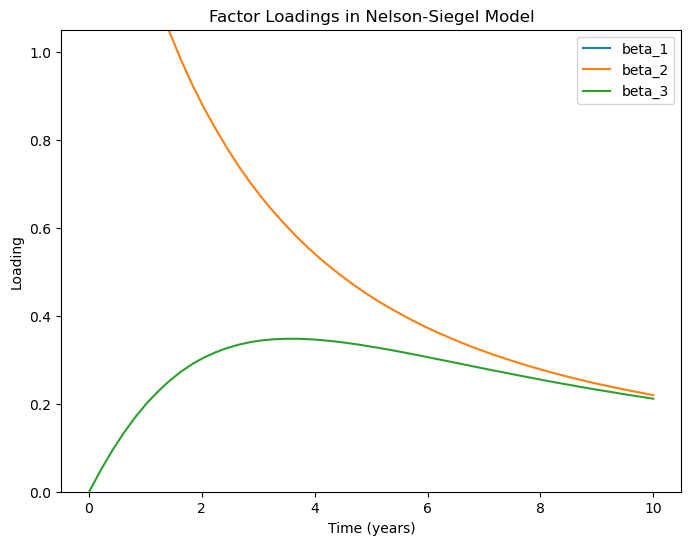

In [25]:
plt.figure(figsize = (8,6))
plt.plot(times,scale(factor1loading,1),label='beta_1');
plt.plot(times,scale(factor2loading,1),label='beta_2');
plt.plot(times,scale(factor3loading,1),label='beta_3');
plt.ylim((0,1.05))

plt.title('Factor Loadings in Nelson-Siegel Model');
plt.xlabel('Time (years)');
plt.ylabel('Loading');
plt.legend(loc='best')

In [26]:
beta_1 = 0.03
beta_2 = -0.02
beta_3 = -0.02
beta_4 = 0.08
curve1 = NSSDiscountCurve(curve_dt, beta_1, beta_2, beta_3, beta_4, tau_1, tau_2)
zero_rates1 = curve1.zero_rate(dates)

In [27]:
beta_1 = 0.04
beta_2 = -0.02
beta_3 = -0.02
beta_4 = 0.08
curve2 = NSSDiscountCurve(curve_dt, beta_1, beta_2, beta_3, beta_4, tau_1, tau_2)
zero_rates2 = curve2.zero_rate(dates)

In [28]:
beta_1 = 0.05
beta_2 = -0.02
beta_3 = -0.02
beta_4 = 0.08
curve3 = NSSDiscountCurve(curve_dt, beta_1, beta_2, beta_3, beta_4, tau_1, tau_2)
zero_rates3 = curve3.zero_rate(dates)

In [29]:
beta_1 = 0.06
beta_2 = -0.02
beta_3 = -0.02
beta_4 = 0.08
curve4 = NSSDiscountCurve(curve_dt, beta_1, beta_2, beta_3, beta_4, tau_1, tau_2)
zero_rates4 = curve4.zero_rate(dates)

In [30]:
beta_1 = 0.07
beta_2 = -0.02
beta_3 = -0.02
beta_4 = 0.08
curve5 = NSSDiscountCurve(curve_dt, beta_1, beta_2, beta_3, beta_4, tau_1, tau_2)
zero_rates5 = curve5.zero_rate(dates)

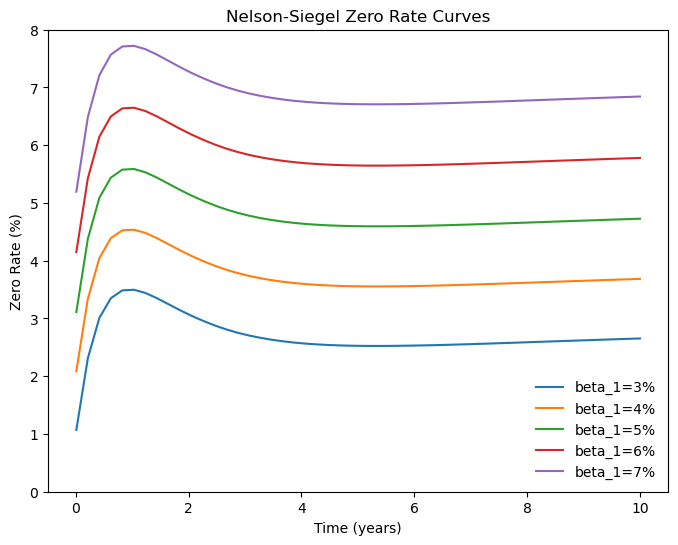

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(times, scale(zero_rates1, 100), label='beta_1=3%')
plt.plot(times, scale(zero_rates2, 100), label='beta_1=4%')
plt.plot(times, scale(zero_rates3, 100), label='beta_1=5%')
plt.plot(times, scale(zero_rates4, 100), label='beta_1=6%')
plt.plot(times, scale(zero_rates5, 100), label='beta_1=7%')
plt.ylim((0, 8))

plt.title('Nelson-Siegel Zero Rate Curves')
plt.xlabel('Time (years)')
plt.ylabel('Zero Rate (%)')
plt.legend(loc='lower right', frameon=False)

In [32]:
maturity_dt = curve_dt.add_years(5.0)

In [33]:
curve1.df(maturity_dt)

0.8825953492695428

In [34]:
curve1.zero_rate(maturity_dt)

0.02526421228424125

In [35]:
curve1.fwd_rate(maturity_dt, "1M")

0.024075780668836776

In [36]:
curve1.fwd_rate_inst(maturity_dt)

0.02430124886663078

Copyright (c) 2020 Dominic O'Kane